# Chapter 4: Targeted Engineering Problems

---

This chapter introduces the engineering benchmark problems that the quantum algorithms of later chapters will target. Each is a workhorse of computational mechanics, chosen because it is small enough to be tractable yet rich enough to exercise linear-system solving and optimization. We cover **truss** structures (§4.1), **Poisson** problems in 1D and 2D via finite differences and finite elements (§4.2), **plane-stress** continuum analysis and topology optimization (§4.3), and **microstructural homogenization** (§4.4).

Everything here runs classically, through the clean `Chapter04_EngineeringProblems_functions.py` interface. These classical results serve as the ground truth against which quantum solutions are later compared.

**Prerequisites:**
- See `Chapter02_QuantumSoftware_notebook.ipynb` for installation instructions

In [1]:
# Setup and imports for D-Wave
import numpy as np
import matplotlib.pyplot as plt


print('Setup complete!')

Setup complete!


## Pick a truss example  *(Book §4.1.1–4.1.2, Example 4.1)*
A truss is the simplest structural system that still captures the essential challenges of engineering analysis and optimization. This ground structure is a $3\times3$ grid of 9 nodes joined by up to 28 potential members, pinned at the two bottom corners and loaded at the top center. Each member carries only axial force and is modeled as a two-node element with two DOFs per node. The pre-built `truss3x3` configuration ($E=200$ GPa, $A=5\times10^{-4}\,\mathrm{m}^2$) is imported directly.

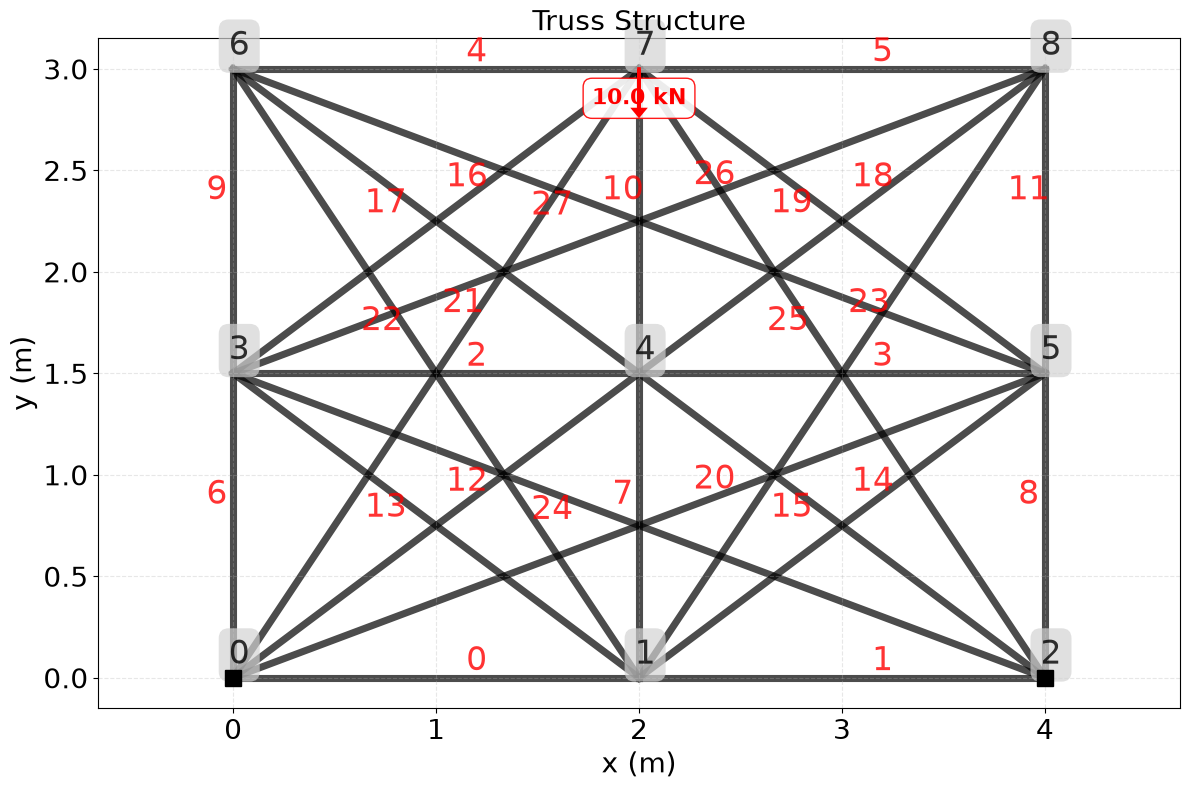

In [2]:
from Chapter04_EngineeringProblems_functions import truss3x3
fem_model= truss3x3() 
fem_model.plot_truss(show_labels = True)

## Solving and plotting the deformed truss  *(Book §4.1.2, Listing 4.1)*
Element stiffness matrices $K_e=\tfrac{E_eA_e}{L_e}T_e$ are assembled into the global matrix $\hat K$; boundary conditions eliminate the pinned DOFs, leaving the reduced system $Kd=f$. After solving, the full displacement vector is reconstructed by reinserting zeros at the constrained DOFs. The plot shows the deformed shape, with displacements scaled for visibility.

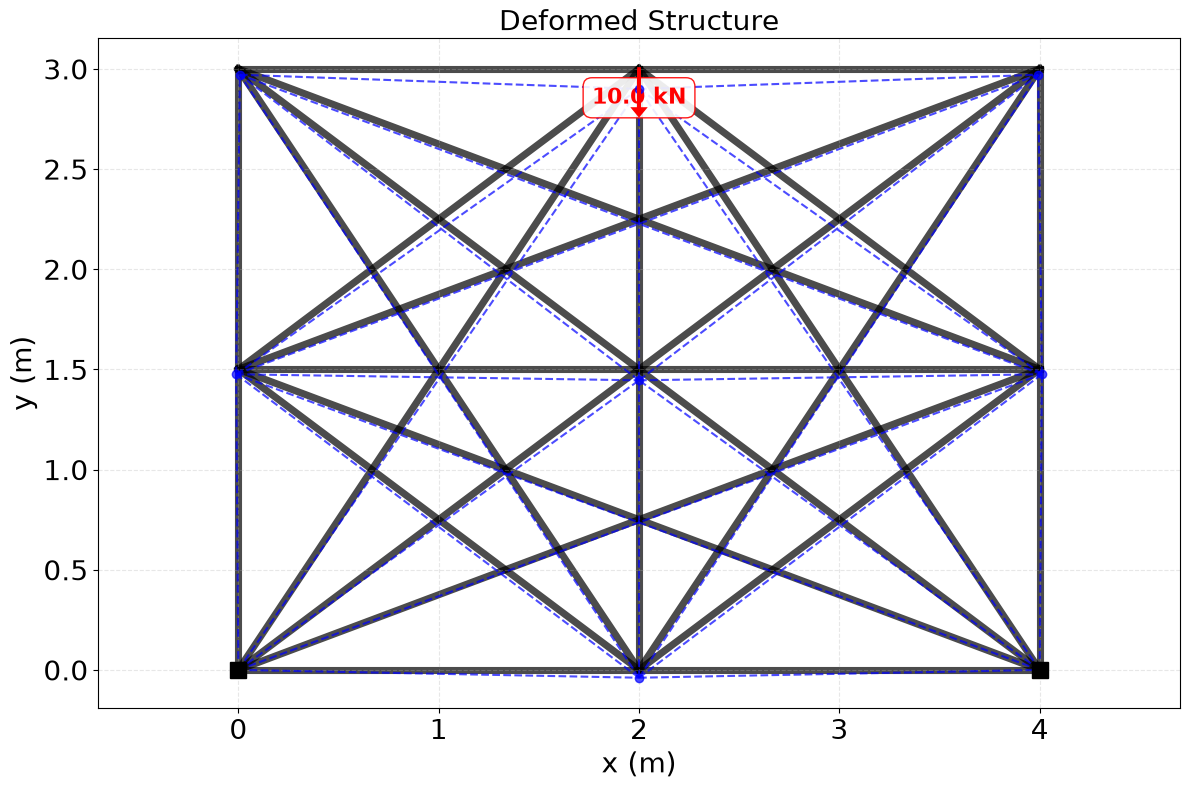

In [3]:
# Solve FEM for full design
d, valid = fem_model.solve()

# plot deformed truss
fem_model.plot_truss(displacements=d, 
                    title="Deformed Structure")


## Evaluating the design metrics  *(Book §4.1.1–4.1.2)*
From the displacements we derive the key structural quantities: total material **volume**, maximum nodal **displacement**, maximum member **stress**, and **compliance** $\phi=f^{T}d$ — a scalar measure of overall deformation (lower is stiffer). These metrics define the objective and constraints for the optimization that follows.

  Volume: 0.0363
  Max displacement: 0.0001158
  Max stress: 7.03e+06
  Compliance: 1.16


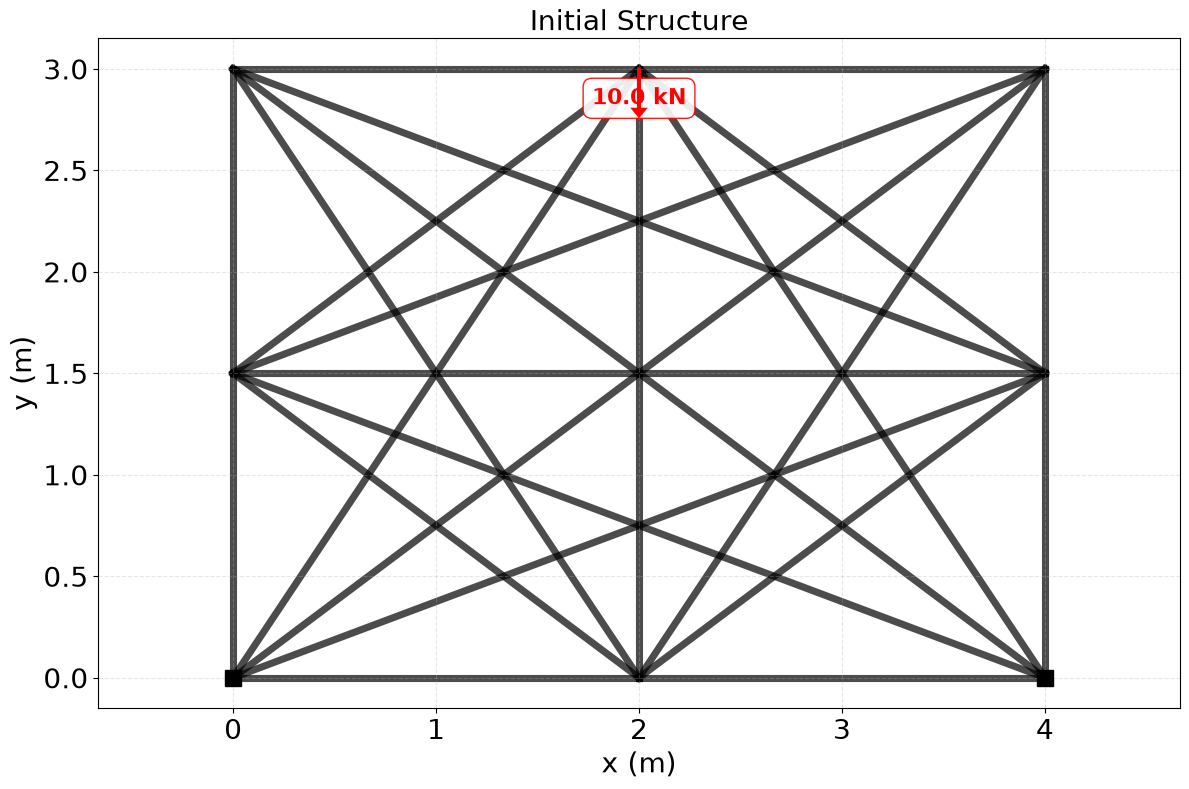

In [4]:
# Design constraints

metrics = fem_model.evaluate_design()
fem_model.print_metrics(metrics)
fem_model.plot_truss(title="Initial Structure")

## Optimizing the truss  *(Book §4.1.5–4.1.6, Example 4.2, Listing 4.2)*
We now solve the **continuous** optimization: minimize compliance $\phi=f^{T}d$ subject to a volume constraint, letting each member area vary above a small lower bound. Unlike the binary and discrete formulations (both NP-hard), the continuous problem is convex and efficiently solved by gradient-based methods — here SciPy's SLSQP with analytical sensitivities $d\phi/d\xi_e=-A^0_e E L_e \varepsilon_e^2$. With `volume_fraction=0.5` (half the material), the optimizer redistributes material along the dominant load paths and compliance drops from about $1.16$ J to $0.761$ J.

Initial volume: 0.0363 m^3
Starting optimization (Target Volume: 0.5000 fraction)...
 Optimization successful.
Final volume: 0.0181 m^3
  Volume: 0.0181
  Max displacement: 7.609e-05
  Max stress: 3.51e+06
  Compliance: 0.761


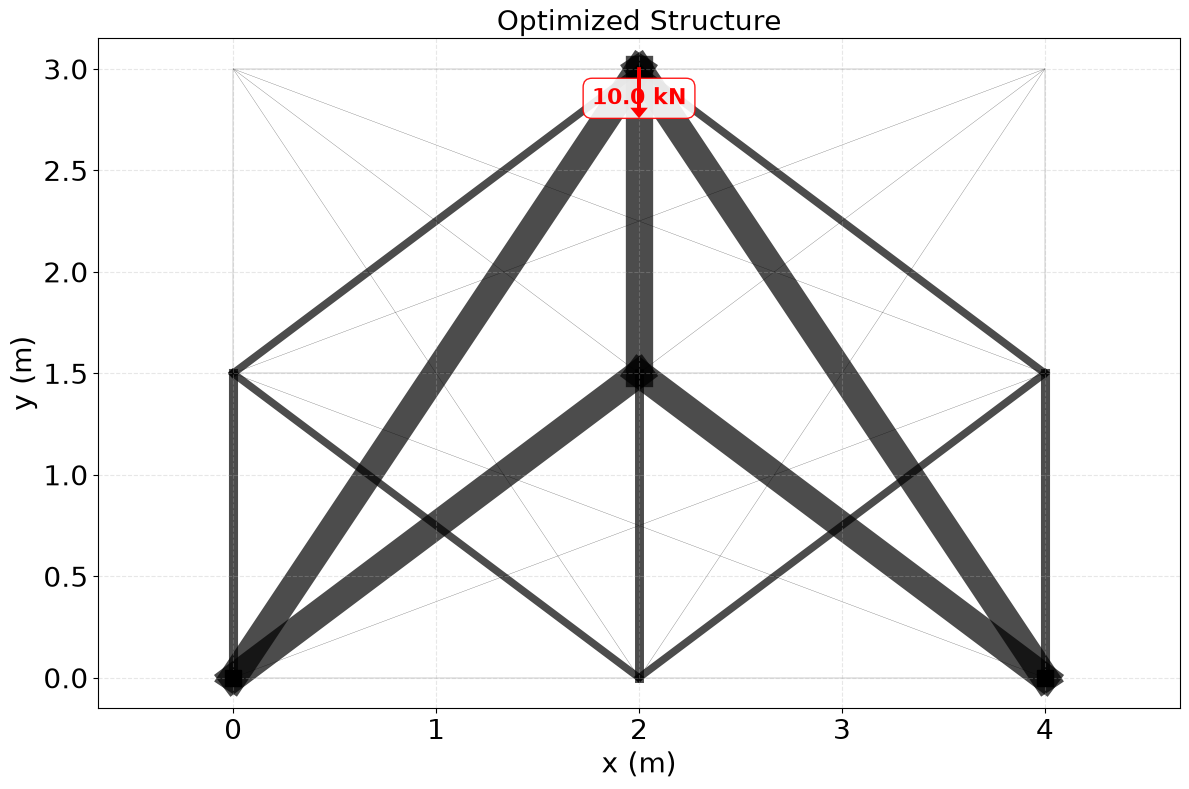

In [5]:
result = fem_model.optimize_areas(volume_fraction = 0.5)
metrics = fem_model.evaluate_design()
fem_model.print_metrics(metrics)
fem_model.plot_truss(title="Optimized Structure")

## Poisson problems  *(Book §4.2)*
The Poisson equation ($-\nabla^2 u = f$) appears throughout science and engineering — heat conduction, electrostatics, potential flow, structural mechanics. Its discretization produces the archetypal *sparse* linear system, making it an ideal test case for quantum linear solvers. We work through 1D and 2D versions using both finite-difference and finite-element discretizations.

### 1D Poisson  *(Book §4.2.1, Example 4.3, Listing 4.3)*
Discretizing $\tfrac{d^2u}{dx^2}=-f$ on $[0,1]$ with homogeneous Dirichlet ends and the central-difference stencil yields the tridiagonal system with the canonical $[-1,\,2,\,-1]$ rows. With 20 elements and a uniform source $f=1$, the numerical solution reproduces the parabola $u(x)=x(1-x)/2$, confirming the implementation. This tridiagonal matrix reappears in several quantum circuit constructions later in the text.

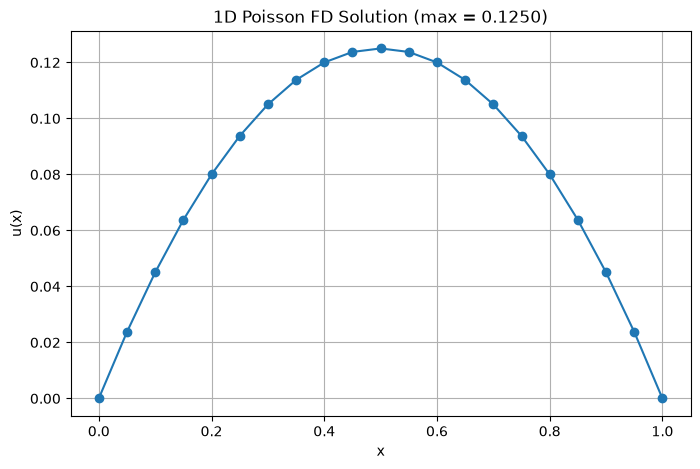

In [6]:
from Chapter04_EngineeringProblems_functions import Poisson1DFD

poisson1DFD = Poisson1DFD(n_elements=20, length=1.0)
u1D = poisson1DFD.solve()
poisson1DFD.plot_solution(u1D)

### 1D periodic Poisson problem  *(Book §4.2.2, Example 4.4, Listing 4.4)*
A repeating (ring) domain with periodic boundary conditions instead of fixed ends. Wrap-around coupling places $-1$ in the two matrix corners, giving a **circulant** matrix that is symmetric but *singular* (every row sums to zero). Two consequences follow: the load must be **self-equilibrated** ($\int f\,dx = 0$), and the solution is pinned by a **zero-mean** condition ($\sum_i u_i = 0$). Here $f(x)=\sin(2\pi x)$ satisfies solvability, and the exact zero-mean solution is $u(x)=\sin(2\pi x)/(2\pi)^2$. This periodic problem is the 1D prototype for the representative volume element used in homogenization (§4.4).

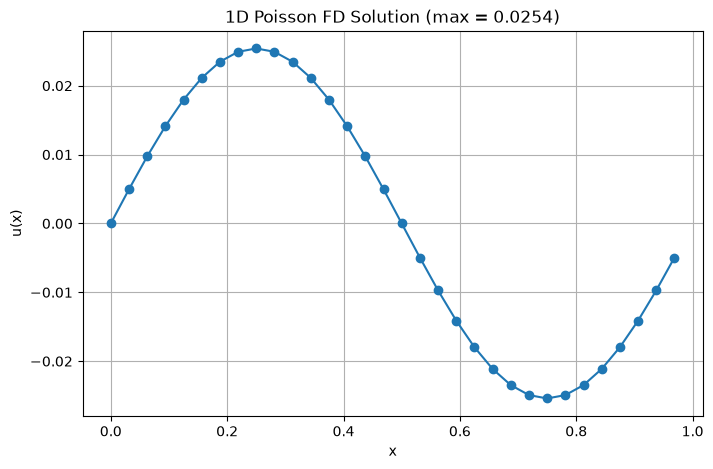

In [7]:
from Chapter04_EngineeringProblems_functions import Poisson1DFD
import numpy as np

poisson1DFDPeriodic = Poisson1DFD(n_elements=32, length=1.0, boundary='periodic',
                                  f=lambda x: np.sin(2*np.pi*x))
uPeriodic = poisson1DFDPeriodic.solve()
poisson1DFDPeriodic.plot_solution(uPeriodic)

### 2D Poisson: finite difference  *(Book §4.2.3)*
Extending to a rectangular domain with homogeneous Dirichlet boundaries, the second-order central scheme in both directions produces the classic **five-point stencil**: $2(1+r)u_{m,n}-(u_{m-1,n}+u_{m+1,n})-r(u_{m,n-1}+u_{m,n+1})=h_x^2 f_{m,n}$, where $r=h_x^2/h_y^2$. On a uniform $20\times20$ grid this yields a block-tridiagonal system that we solve and plot as a surface.

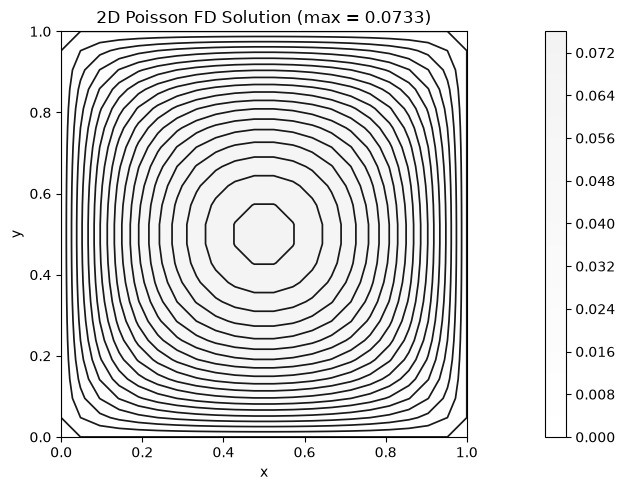

In [8]:
from Chapter04_EngineeringProblems_functions import Poisson2DFD

poisson2DFD = Poisson2DFD(nx=20, ny=20, Lx=1.0, Ly=1.0)
u2D = poisson2DFD.solve()
poisson2DFD.plot_solution(u2D)

### 2D Poisson: finite element  *(Book §4.2.4)*
The finite element method offers a more flexible alternative using bilinear quadrilateral elements, with element stiffness $K^e_{ij}=\int_{\Omega_e}\nabla N_i\cdot\nabla N_j\,d\Omega$. This gives a denser **nine-point stencil**, and the assembled $K$ stays symmetric positive-definite. Notably $K$ admits a **tensor-product** form built from the 1D stiffness and mass matrices $K_{1D}$ and $M_{1D}$ — a structure we exploit when building quantum circuits later.

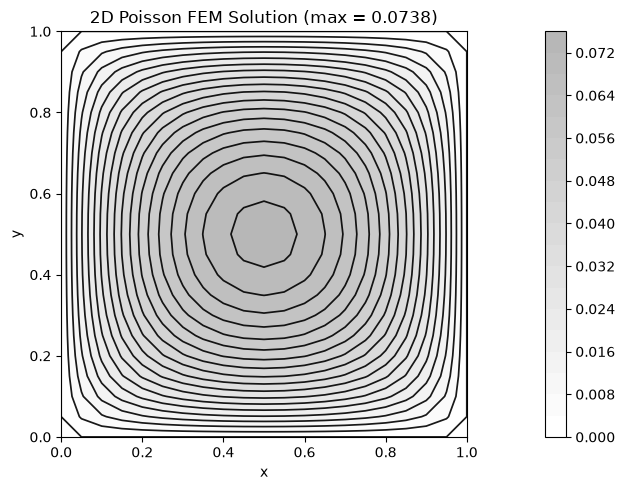

In [9]:
from Chapter04_EngineeringProblems_functions import Poisson2DFE

poisson2DFE = Poisson2DFE(nx=20, ny=20, Lx=1.0, Ly=1.0)
u2D = poisson2DFE.solve()
poisson2DFE.plot_solution(u2D)

## Plane stress example  *(Book §4.3–4.3.1, Figure 4.12)*
Trusses carry only axial force; a **plane-stress** problem adds bending, shear, and distributed stress in a 2D continuum. We analyze a cantilever beam fixed along its left edge and loaded at the right, discretized with bilinear quadrilateral elements ($60\times30$). Each node now has two DOFs coupled through the elasticity matrix $D$, producing a $2\times2$ block structure at every nodal coupling.

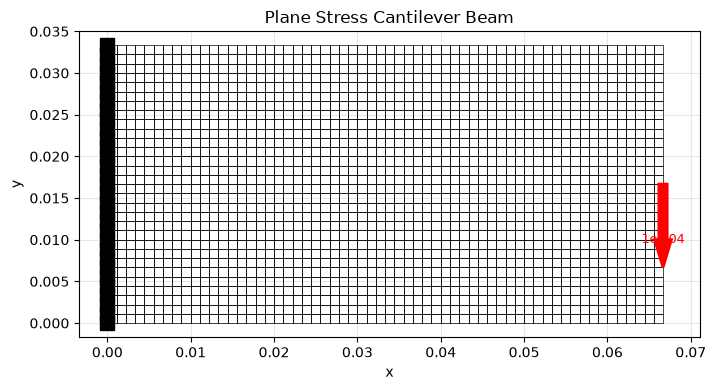

In [10]:
from Chapter04_EngineeringProblems_functions import PlaneStressCantilever

fea2d = PlaneStressCantilever(nx=60, ny=30,)
fea2d.plot_mesh()


## Solve the plane-stress problem  *(Book §4.3.2)*
We assemble the global stiffness ($K^e_{ij}=\int_{\Omega_e}B_i^{T}DB_j\,d\Omega$), apply the fixed-edge boundary conditions, and solve $Ku=f$ for the displacement field. The metrics and the displacement plot characterize how the cantilever deforms under the tip load.

  Compliance: 0.1977
  Volume: 0.0002222
  Volume fraction: 1.0000


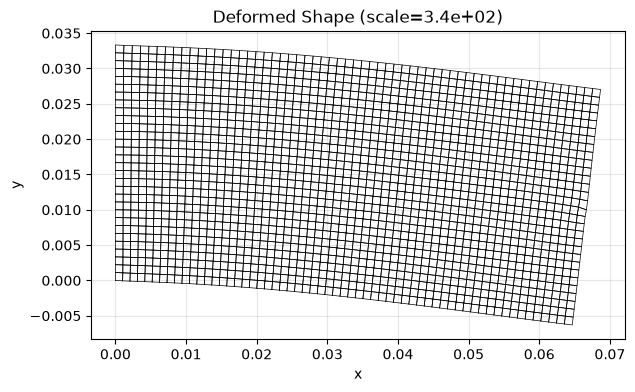

In [11]:

U, valid = fea2d.solve()
metrics = fea2d.evaluate_design()
fea2d.print_metrics(metrics)

fea2d.plot_displacement()

## Plane-stress topology optimization  *(Book §4.3.3, Example 4.8, Listing 4.8)*
The **optimality criteria (OC)** method solves the continuous topology-optimization problem for the cantilever. It uses SIMP material interpolation, $E(\xi)=E_0\,\xi^{p}$ with $p=3$, to penalize intermediate densities and drive toward a clear black-and-white layout; a Lagrange multiplier $\lambda$ (found by bisection) enforces the volume constraint, and a sensitivity filter suppresses checkerboarding. `PlaneStressOC` reuses the existing `fea2d` model, so no geometry is redefined. Optimizing for a volume fraction of $0.5$ produces the classic arch-and-strut topology that channels the load to the support.

Starting OC Optimization: Target VF=0.5, Filter R=1.5
Iter   0: Compliance=1.582, volume_fraction=0.5000, Change=0.2000
Iter   5: Compliance=0.5171, volume_fraction=0.5000, Change=0.2000
Iter  10: Compliance=0.4091, volume_fraction=0.5002, Change=0.1954
Iter  15: Compliance=0.3463, volume_fraction=0.5000, Change=0.1565
Iter  20: Compliance=0.3344, volume_fraction=0.5000, Change=0.0522
Iter  25: Compliance=0.3337, volume_fraction=0.5000, Change=0.0320
Iter  30: Compliance=0.3333, volume_fraction=0.5000, Change=0.0212
Iter  35: Compliance=0.3331, volume_fraction=0.5001, Change=0.0159
Iter  40: Compliance=0.3331, volume_fraction=0.5000, Change=0.0121
Iter  45: Compliance=0.3329, volume_fraction=0.5001, Change=0.0139
Iter  50: Compliance=0.333, volume_fraction=0.5000, Change=0.0149
Iter  55: Compliance=0.3328, volume_fraction=0.5001, Change=0.0114
Iter  60: Compliance=0.3329, volume_fraction=0.4999, Change=0.0114
Iter  65: Compliance=0.3329, volume_fraction=0.4999, Change=0.0105
Iter  70: 

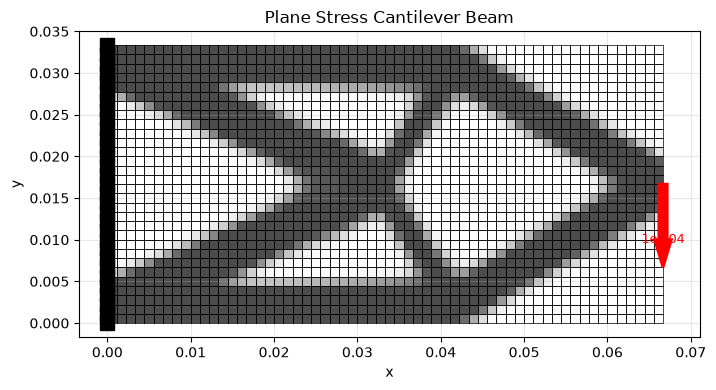

In [12]:
from Chapter04_EngineeringProblems_functions import PlaneStressOC

toOC = PlaneStressOC(fea2d, volume_fraction = 0.5)
toOC.optimize()
fea2d.plot_mesh()

## Microstructure  *(Book §4.4, Example 4.9, Listing 4.9)*
Composite materials — stiff inclusions in a softer matrix — would need a prohibitively fine mesh to resolve directly. **Homogenization** replaces the heterogeneous microstructure with an equivalent homogeneous material. The first step is to generate the representative volume element (RVE): here a periodic microstructure of four circular inclusions on a $40\times40$ grid.

Target inclusion fraction: 0.100
Actual inclusion fraction: 0.093
1452.0


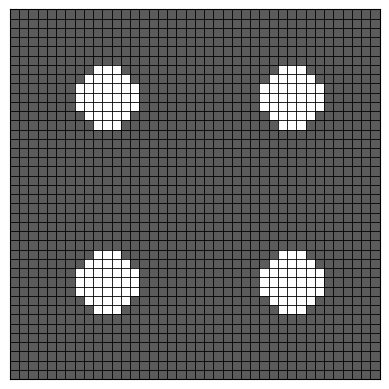

In [13]:
from Chapter04_EngineeringProblems_functions import MicrostructureGenerator

microstructure = MicrostructureGenerator(nx=40, ny=40, inclusion_fraction=0.1, micro_type='4disks')
print(microstructure.data.sum())
microstructure.plot()

### Homogenization  *(Book §4.4, Listing 4.11)*
Given the microstructure and the phase properties (inclusion $E=10$, matrix $E=1$, both $\nu=0.3$), an FEA-based homogenization solves three unit-strain cell problems to build the effective stiffness tensor $C^H$, from which we extract the homogenized Young's modulus and Poisson's ratio. As expected, the homogenized modulus ($\approx1.41$) lies between the matrix ($1.0$) and inclusion ($10.0$) values, weighted by inclusion volume fraction and topology.

In [14]:
from Chapter04_EngineeringProblems_functions import FEA2DHomogenize

E_incl, nu_incl = 10, 0.3
E_matrix, nu_matrix = 1, 0.3

# Create class instance and use its methods
fea = FEA2DHomogenize()


CH = fea.fea_homogenize(E_incl, nu_incl, E_matrix, nu_matrix, microstructure.data)
print('\nHomogenized elasticity tensor CH:')
print(CH)
E_hom, nu_hom = fea.get_E_nu_from_C(CH)
print(f"Homogenized Young's modulus: {E_hom:.4f}")
print(f"Homogenized Poisson's ratio: {nu_hom:.4f}")

K_hom = E_hom / (3 * (1 - 2 * nu_hom))
G_hom = E_hom / (2 * (1 + nu_hom))

print(f"Homogenized bulk modulus: {K_hom:.4f}")
print(f"Homogenized shear modulus: {G_hom:.4f}")


--- Homogenization of 2D plane-strain periodic material ---

Homogenized elasticity tensor CH:
[[ 1.09048002e+01  4.45836116e+00 -2.25180985e-15]
 [ 4.45836116e+00  1.09048002e+01 -1.22818422e-16]
 [-2.16826557e-15 -1.41830991e-16  3.12255215e+00]]
Homogenized Young's modulus: 8.0574
Homogenized Poisson's ratio: 0.2902
Homogenized bulk modulus: 6.4008
Homogenized shear modulus: 3.1226
